In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
BostonTrain = pd.read_csv(r"F:\COLLEGE\NOTES\6TH SEM\ML Lab\Datasets\boston.csv")

In [4]:
BostonTrain.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
BostonTrain.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [6]:
BostonTrain.info()
BostonTrain.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: xlabel='RM', ylabel='MEDV'>

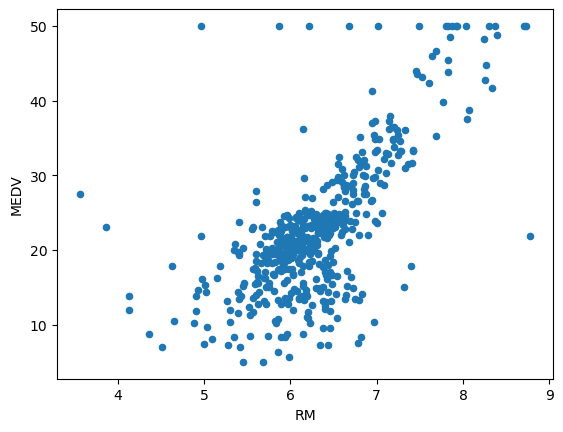

In [7]:
BostonTrain.plot.scatter('RM', 'MEDV')

<Axes: >

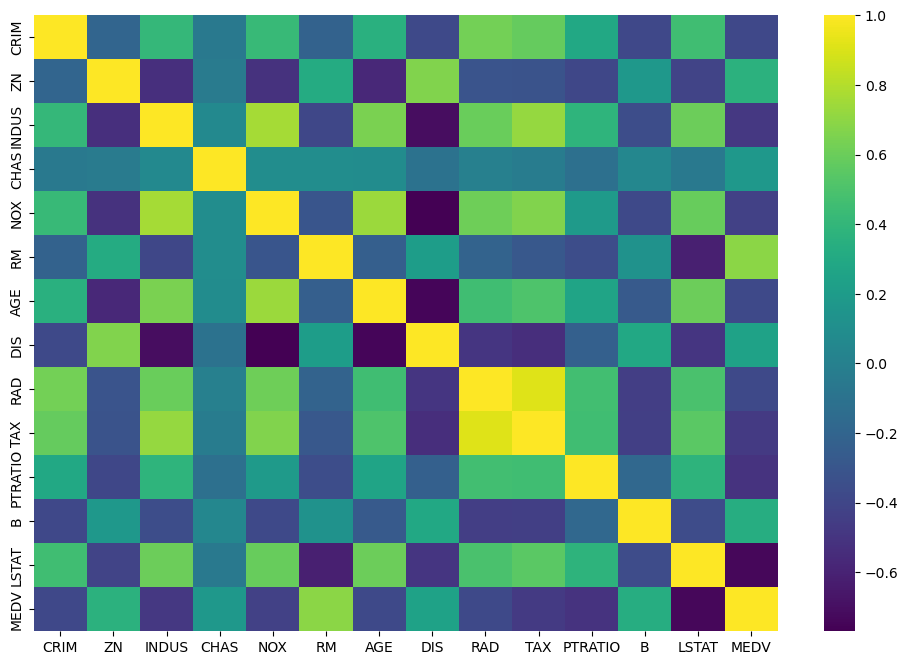

In [22]:
plt.subplots(figsize=(12,8))
sns.heatmap(BostonTrain.corr(), cmap = 'viridis')

In [9]:
X = BostonTrain[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT']]
y = BostonTrain['MEDV']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

In [13]:
predictions = lm.predict(X_test)

Text(0, 0.5, 'Predicted Y')

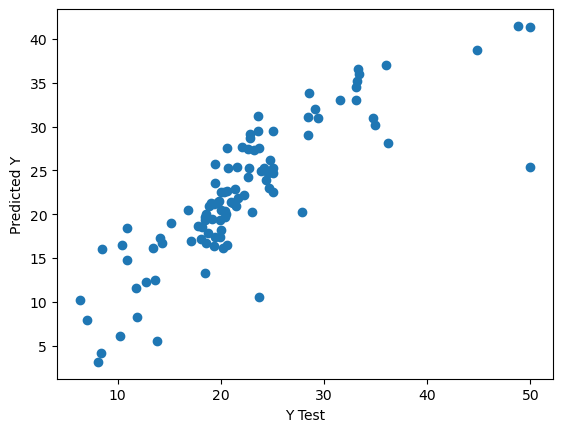

In [14]:
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

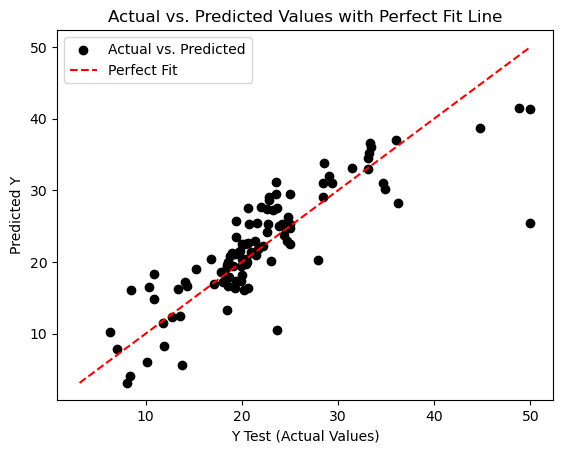

In [15]:
plt.scatter(y_test, predictions, color='black', label='Actual vs. Predicted')
# Add a line representing perfect predictions (y = x)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Y Test (Actual Values)')
plt.ylabel('Predicted Y')
plt.title('Actual vs. Predicted Values with Perfect Fit Line')
plt.legend()
plt.show()

In [25]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 3.1845544198711657
MSE: 20.873393450809214
RMSE: 4.568740904320272


In [23]:
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder

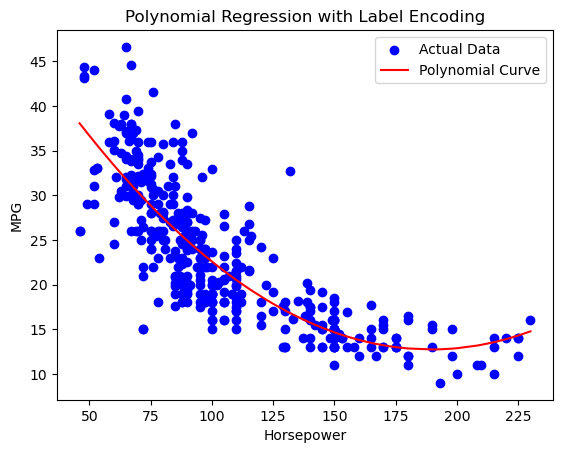

In [24]:
# Load dataset
df = pd.read_csv(r'F:\COLLEGE\NOTES\6TH SEM\ML Lab\Datasets\auto-mpg.csv')

# Replace '?' with NaN in 'horsepower' column
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert 'horsepower' to numeric and then drop missing values
df['horsepower'] = pd.to_numeric(df['horsepower'])
df = df.dropna()

# Label Encoding for last column (car name)
le = LabelEncoder()
df.iloc[:, -1] = le.fit_transform(df.iloc[:, -1])

# Select feature and target
X = df[['horsepower']].values   # independent variable
y = df['mpg'].values            # dependent variable

# Polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

# Predict
y_pred = model.predict(X_poly)

# Sort values for smooth curve
sorted_index = X[:, 0].argsort()
X_sorted = X[sorted_index]
y_sorted = y_pred[sorted_index]

# Plot graph
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_sorted, y_sorted, color='red', label='Polynomial Curve')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Polynomial Regression with Label Encoding')
plt.legend()
plt.show()